# Assignment 2 — Sanskrit → English NMT
## Full fine-tuning of AI4Bharat IndicTrans2 (Indic→En, distilled, ~200M params)

**Structure of this notebook — 10 independent modules (MODULE 0 → MODULE 9).**
Each module is a self-contained cell block: it declares what it *needs* and what it
*produces*, and it **auto-recovers its inputs from disk** (under `STORAGE_PATH`) if they
aren't already sitting in memory. That means:

- You can re-run **any single module** on its own without re-running the ones before it,
  as long as that module's prerequisite artifacts were saved to disk at least once.
- This also survives a Colab **runtime restart** — e.g. after training finishes and you
  disconnect, you can reconnect, run MODULE 0 (fast) and MODULE 6 (inference) directly,
  skipping data loading and the multi-epoch training loop entirely.

**Pretrained-model disclosure** (cleared with TA): this fine-tunes the public checkpoint
`ai4bharat/indictrans2-indic-en-dist-200M` (AI4Bharat, MIT license) on the **provided**
`train_sa.csv`/`train_en.csv` pairs only — no external translation API is called, only a
one-time model-weights download from the Hugging Face Hub. State this in the Report.

| Module | Name | Needs (from disk if not in memory) | Produces (saved to disk) |
|---|---|---|---|
| 0 | Setup & Config | — | `Cfg`, mounted Drive |
| 1 | Data Loading | provided CSVs | `train_df.pkl`, `dev_df.pkl`, `test_df.pkl` |
| 2 | Model/Tokenizer/IndicProcessor | HF Hub | `pristine_model_state.pt` |
| 3 | Dataset & DataLoader | Module 1 + 2 outputs | in-memory only (cheap to rebuild) |
| 4 | Training loop | Module 2/3 outputs | `best_finetuned.pt`, `history.json` |
| 5 | Training curves plot | `history.json` | `training_curves.png` |
| 6 | Test-set beam-search inference | `best_finetuned.pt` + `test_df.pkl` | `test_predictions.csv` |
| 7 | Metrics (BLEU/BERTScore/Efficiency) | `test_predictions.csv` | `metrics.json` |
| 8 | Write `submission.csv` | `test_predictions.csv` | `submission.csv` |
| 9 | Report examples table | `test_predictions.csv` | — (display only) |


---
## MODULE 0 — Setup, dependencies, config, Drive mount
**Needs:** nothing. **Produces:** `Cfg` (global config), mounted Drive, all imports.
Safe to re-run any time — idempotent (pip installs are quick no-ops if already installed).

In [6]:
# ==============================================================================
# MODULE 0: SETUP & CONFIG
# ==============================================================================
!pip install -q -U transformers==4.44.2 accelerate sentencepiece sacremoses
!pip install -q -U nltk bert-score
!pip install -q git+https://github.com/VarunGumma/IndicTransToolkit.git

import os, time, random, json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

# HuggingFace API Token stored in Collab Secret Key variable
from google.colab import userdata
from huggingface_hub import login
login(token=userdata.get('HF_TOKEN'))

from google.colab import drive
drive.mount('/content/drive')

STORAGE_PATH = '/content/drive/MyDrive/Sanskrit_NMT_Project'
os.makedirs(STORAGE_PATH, exist_ok=True)
os.environ["TOKENIZERS_PARALLELISM"] = "false"

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

class Cfg:
    MODEL_NAME       = "ai4bharat/indictrans2-indic-en-dist-200M"
    SRC_LANG         = "san_Deva"
    TGT_LANG         = "eng_Latn"
    DATA_DIR         = STORAGE_PATH   # where train_sa.csv etc live; change if different
    MAX_SRC_LEN      = 160
    MAX_TGT_LEN      = 160
    TRAIN_BATCH      = 8
    EVAL_BATCH       = 16
    GRAD_ACC_STEPS   = 4
    EPOCHS           = 6
    LR               = 1.5e-5
    WEIGHT_DECAY     = 0.01
    WARMUP_RATIO     = 0.05
    NUM_BEAMS        = 5
    LABEL_SMOOTHING  = 0.1
    PATIENCE         = 2
    FP16             = True
    PRISTINE_PATH    = os.path.join(STORAGE_PATH, "pristine_model_state.pt")
    BEST_CKPT_PATH   = os.path.join(STORAGE_PATH, "best_finetuned.pt")
    HISTORY_PATH     = os.path.join(STORAGE_PATH, "history.json")
    PRED_PATH        = os.path.join(STORAGE_PATH, "test_predictions.csv")
    METRICS_PATH     = os.path.join(STORAGE_PATH, "metrics.json")
    SUBMISSION_PATH  = os.path.join(STORAGE_PATH, "submission.csv")
    TRAIN_DF_PKL     = os.path.join(STORAGE_PATH, "train_df.pkl")
    DEV_DF_PKL       = os.path.join(STORAGE_PATH, "dev_df.pkl")
    TEST_DF_PKL      = os.path.join(STORAGE_PATH, "test_df.pkl")

print(json.dumps({k:v for k,v in vars(Cfg).items() if not k.startswith('_')}, indent=2, default=str))


  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cuda
{
  "MODEL_NAME": "ai4bharat/indictrans2-indic-en-dist-200M",
  "SRC_LANG": "san_Deva",
  "TGT_LANG": "eng_Latn",
  "DATA_DIR": "/content/drive/MyDrive/Sanskrit_NMT_Project",
  "MAX_SRC_LEN": 160,
  "MAX_TGT_LEN": 160,
  "TRAIN_BATCH": 8,
  "EVAL_BATCH": 16,
  "GRAD_ACC_STEPS": 4,
  "EPOCHS": 6,
  "LR": 1.5e-05,
  "WEIGHT_DECAY": 0.01,
  "WARMUP_RATIO": 0.05,
  "NUM_BEAMS": 5,
  "LABEL_SMOOTHING": 0.1,
  "PATIENCE": 2,
  "FP16": true,
  "PRISTINE_PATH": "/content/drive/MyDrive/Sanskrit_NMT_Project/pristine_model_state.pt",
  "BEST_CKPT_PATH": "/content/drive/MyDrive/Sanskrit_NMT_Project/best_finetuned.pt",
  "HISTORY_PATH": "/content/drive/MyDrive/Sanskrit_NMT_Project/history.json",
  "PRED_PATH": "/content/drive/

---
## MODULE 1 — Data loading
**Needs:** `Cfg` (Module 0) + provided `train_sa.csv`/`train_en.csv`/`dev_sa.csv`/`dev_en.csv`/`test_sa.csv`/`test_en.csv` under `Cfg.DATA_DIR`.
**Produces:** `train_df`, `dev_df`, `test_df` in memory, and pickled to disk so this module
never needs to re-run just to make the dataframes available to later modules.

In [3]:
# ==============================================================================
# MODULE 1: DATA LOADING  (re-run this alone any time the CSVs change)
# ==============================================================================
def load_pair(sa_csv, en_csv):
    sa_df = pd.read_csv(os.path.join(Cfg.DATA_DIR, sa_csv))
    en_df = pd.read_csv(os.path.join(Cfg.DATA_DIR, en_csv))
    df = pd.merge(sa_df, en_df, on='Source_id', how='inner')
    df = df.dropna(subset=['Sentence_sa', 'Sentence_en']).drop_duplicates(subset=['Sentence_sa', 'Sentence_en'])
    df['Sentence_sa'] = df['Sentence_sa'].astype(str).str.strip()
    df['Sentence_en'] = df['Sentence_en'].astype(str).str.strip()
    return df.reset_index(drop=True)

train_df = load_pair('train_sa_10000.csv', 'train_en_10000.csv')
dev_df   = load_pair('dev_sa_1000.csv',   'dev_en_1000.csv')
test_df  = load_pair('test_sa_1000.csv',  'test_en_1000.csv')

train_df.to_pickle(Cfg.TRAIN_DF_PKL)
dev_df.to_pickle(Cfg.DEV_DF_PKL)
test_df.to_pickle(Cfg.TEST_DF_PKL)

print(f"train={len(train_df)}  dev={len(dev_df)}  test={len(test_df)}  (saved .pkl to {Cfg.DATA_DIR})")
train_df.head()


train=9990  dev=1000  test=1000  (saved .pkl to /content/drive/MyDrive/Sanskrit_NMT_Project)


,Source_id,Sentence_sa,Sentence_en
0,1,"""Ctrl, S नुत्वा रक्षन्तु।""","Save it with Ctrl, S."
1,2,गुरुः छात्रान् एकवारं पाठयति ।,Teacher will teach the students only once.
2,3,चित्रचालनमिदं पुनः कर्तुं मया अस्याः राशेः चित...,"To recreate this animation, I have to take two..."
3,4,वयं Colors विकल्पं तस्योपरि नोदनेन चिनुमः ।,I will choose Colors options by clicking on it.
4,5,"""अत्र कानिचन उदाहरणानि पश्याम:- एक: पर्वत:, चत...","""See the example here - one mountain, four vil..."


---
## MODULE 2 — Load IndicTrans2 model, tokenizer, IndicProcessor
**Needs:** `Cfg` (Module 0). **Produces:** `model`, `tokenizer`, `ip` in memory, and a
**pristine (never-trained) copy of the weights** saved to disk (`Cfg.PRISTINE_PATH`).
That pristine copy is what MODULE 4 resets to at the start of every training run, so
re-running MODULE 4 alone always starts fine-tuning from the original checkpoint —
never from a half-crashed / already-fine-tuned in-memory state.

This is the expensive-to-download module — safe to run once per session and leave alone.

In [7]:
# ==============================================================================
# MODULE 2: MODEL / TOKENIZER / INDICPROCESSOR  (full fine-tune: nothing frozen)
# ==============================================================================
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
from IndicTransToolkit.processor import IndicProcessor

tokenizer = AutoTokenizer.from_pretrained(Cfg.MODEL_NAME, trust_remote_code=True)
model = AutoModelForSeq2SeqLM.from_pretrained(Cfg.MODEL_NAME, trust_remote_code=True).to(DEVICE)
ip = IndicProcessor(inference=True)

for p in model.parameters():
    p.requires_grad = True   # explicit: full fine-tune, no frozen layers, no LoRA

if not os.path.exists(Cfg.PRISTINE_PATH):
    torch.save(model.state_dict(), Cfg.PRISTINE_PATH)
    print("Saved pristine (pretrained, not-yet-fine-tuned) weights ->", Cfg.PRISTINE_PATH)
else:
    print("Pristine checkpoint already exists at", Cfg.PRISTINE_PATH, "- leaving it untouched.")

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}  (100% — full fine-tune)")


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenization_indictrans.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/ai4bharat/indictrans2-indic-en-dist-200M:
- tokenization_indictrans.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


dict.SRC.json: 0.00B [00:00, ?B/s]

dict.TGT.json: 0.00B [00:00, ?B/s]

...

modeling_indictrans.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/ai4bharat/indictrans2-indic-en-dist-200M:
- modeling_indictrans.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


model.safetensors:   0%|          | 0.00/913M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/163 [00:00<?, ?B/s]

Saved pristine (pretrained, not-yet-fine-tuned) weights -> /content/drive/MyDrive/Sanskrit_NMT_Project/pristine_model_state.pt
Total parameters:     211,780,608
Trainable parameters: 211,780,608  (100% — full fine-tune)


---
## MODULE 3 — Dataset / DataLoader construction
**Needs:** `train_df`, `dev_df` (Module 1, auto-loaded from `.pkl` if missing) and
`tokenizer`, `ip` (Module 2 — **must** already be in memory; if you restarted the
runtime, run MODULE 0 + MODULE 2 first, this module does not redownload the model).
**Produces:** `train_loader`, `dev_loader` in memory. Cheap — no need to persist to disk.

In [8]:
# ==============================================================================
# MODULE 3: DATASET / DATALOADER
# ==============================================================================
try:
    train_df
except NameError:
    train_df = pd.read_pickle(Cfg.TRAIN_DF_PKL)
try:
    dev_df
except NameError:
    dev_df = pd.read_pickle(Cfg.DEV_DF_PKL)

assert 'tokenizer' in globals() and 'ip' in globals(), \
    "tokenizer/ip not in memory — run MODULE 0 then MODULE 2 first (model must be loaded fresh, not just unpickled)."

class SanskritEnglishDataset(Dataset):
    def __init__(self, df, src_lang, tgt_lang):
        srcs = df['Sentence_sa'].tolist()
        self.srcs_processed = ip.preprocess_batch(srcs, src_lang=src_lang, tgt_lang=tgt_lang)
        self.tgts = df['Sentence_en'].tolist()
    def __len__(self):
        return len(self.tgts)
    def __getitem__(self, idx):
        return self.srcs_processed[idx], self.tgts[idx]

def collate_fn(batch):
    srcs, tgts = zip(*batch)
    model_inputs = tokenizer(list(srcs), truncation=True, padding=True,
                              max_length=Cfg.MAX_SRC_LEN, return_tensors="pt")
    with tokenizer.as_target_tokenizer():
        labels = tokenizer(list(tgts), truncation=True, padding=True,
                            max_length=Cfg.MAX_TGT_LEN, return_tensors="pt").input_ids
    labels[labels == tokenizer.pad_token_id] = -100
    model_inputs["labels"] = labels
    return model_inputs

train_ds = SanskritEnglishDataset(train_df, Cfg.SRC_LANG, Cfg.TGT_LANG)
dev_ds   = SanskritEnglishDataset(dev_df,   Cfg.SRC_LANG, Cfg.TGT_LANG)

train_loader = DataLoader(train_ds, batch_size=Cfg.TRAIN_BATCH, shuffle=True,  collate_fn=collate_fn)
dev_loader   = DataLoader(dev_ds,   batch_size=Cfg.EVAL_BATCH,  shuffle=False, collate_fn=collate_fn)

print(f"train_loader batches={len(train_loader)}  dev_loader batches={len(dev_loader)}")
print("Example preprocessed source:", train_ds.srcs_processed[0])


train_loader batches=1249  dev_loader batches=63
Example preprocessed source: san_Deva eng_Latn " Ctrl , S नुत्वा रक्षन्तु । "


---
## MODULE 4 — Full fine-tuning loop
**Needs:** `model`, `tokenizer` (Module 2), `train_loader`/`dev_loader` (Module 3),
`Cfg.PRISTINE_PATH` on disk (Module 2).
**Produces:** `Cfg.BEST_CKPT_PATH` (best fine-tuned weights by dev BLEU) and
`Cfg.HISTORY_PATH` (loss/BLEU curves) on disk, plus `history` in memory.

**`TRAIN_INIT_MODE`** controls what this module starts from — set it before running:
- `"pretrained"` (default): reset `model` to the pristine, never-trained checkpoint,
  then fine-tune from scratch. Use this for a clean, repeatable training run.
- `"resume_best"`: continue fine-tuning from the last saved *best* checkpoint (useful
  for a few more epochs without restarting from the pretrained weights).
- `"memory"`: use whatever weights are currently loaded in `model` as-is (e.g. you
  changed a hyperparameter mid-session and want to keep going from the current state).

In [9]:
# ==============================================================================
# MODULE 4: TRAINING LOOP
# ==============================================================================
TRAIN_INIT_MODE = "pretrained"   # "pretrained" | "resume_best" | "memory"

assert 'model' in globals() and 'train_loader' in globals() and 'dev_loader' in globals(), \
    "Run MODULE 0 -> MODULE 2 -> MODULE 3 first (model/dataloaders must be in memory)."

if TRAIN_INIT_MODE == "pretrained":
    model.load_state_dict(torch.load(Cfg.PRISTINE_PATH))
    print("Reset model to pristine pretrained weights before training.")
elif TRAIN_INIT_MODE == "resume_best":
    model.load_state_dict(torch.load(Cfg.BEST_CKPT_PATH))
    print("Resumed model from best-saved fine-tuned checkpoint.")
else:
    print("Continuing training from whatever weights are currently in memory.")

from torch.cuda.amp import autocast, GradScaler
from transformers import get_linear_schedule_with_warmup
from nltk.translate.bleu_score import corpus_bleu

optimizer = torch.optim.AdamW(model.parameters(), lr=Cfg.LR, weight_decay=Cfg.WEIGHT_DECAY)
total_steps = (len(train_loader) // Cfg.GRAD_ACC_STEPS) * Cfg.EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer, num_warmup_steps=int(Cfg.WARMUP_RATIO * total_steps), num_training_steps=total_steps
)
scaler = GradScaler(enabled=Cfg.FP16)
loss_fct = nn.CrossEntropyLoss(ignore_index=-100, label_smoothing=Cfg.LABEL_SMOOTHING)

@torch.no_grad()
def quick_dev_bleu(n_batches=8):
    """Cheap dev-set BLEU proxy (greedy decode, few batches) for early stopping only.
    Full beam-search BLEU/BERTScore happens in MODULE 6/7 on the test set."""
    model.eval()
    hyps, refs = [], []
    for i, batch in enumerate(dev_loader):
        if i >= n_batches:
            break
        b = {k: v.to(DEVICE) for k, v in batch.items() if k != 'labels'}
        gen = model.generate(**b, num_beams=1, max_length=Cfg.MAX_TGT_LEN)
        dec = tokenizer.batch_decode(gen, skip_special_tokens=True)
        start = i * Cfg.EVAL_BATCH
        gold = dev_ds.tgts[start:start + len(dec)]
        hyps += [h.split() for h in dec]
        refs += [[g.split()] for g in gold]
    return corpus_bleu(refs, hyps) if hyps else 0.0

history = {"train_loss": [], "dev_bleu": []}
best_bleu, patience_ctr = -1.0, 0

for epoch in range(1, Cfg.EPOCHS + 1):
    model.train()
    running_loss, step_count = 0.0, 0
    optimizer.zero_grad()
    t0 = time.time()

    for step, batch in enumerate(train_loader):
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        with autocast(enabled=Cfg.FP16):
            out = model(**batch)
            logits = out.logits
            loss = loss_fct(logits.view(-1, logits.size(-1)), batch['labels'].view(-1))
            loss = loss / Cfg.GRAD_ACC_STEPS

        scaler.scale(loss).backward()
        running_loss += loss.item() * Cfg.GRAD_ACC_STEPS
        step_count += 1

        if (step + 1) % Cfg.GRAD_ACC_STEPS == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            optimizer.zero_grad()

    avg_loss = running_loss / step_count
    dev_bleu = quick_dev_bleu()
    history["train_loss"].append(avg_loss)
    history["dev_bleu"].append(dev_bleu)
    print(f"Epoch {epoch}/{Cfg.EPOCHS} | train_loss={avg_loss:.4f} | dev_BLEU(greedy,proxy)={dev_bleu:.4f} | {time.time()-t0:.1f}s")

    if dev_bleu > best_bleu:
        best_bleu, patience_ctr = dev_bleu, 0
        torch.save(model.state_dict(), Cfg.BEST_CKPT_PATH)
        print(f"  -> new best (dev BLEU {best_bleu:.4f}), checkpoint saved.")
    else:
        patience_ctr += 1
        if patience_ctr >= Cfg.PATIENCE:
            print("  -> early stopping (no dev-BLEU improvement).")
            break

with open(Cfg.HISTORY_PATH, 'w') as f:
    json.dump(history, f)

model.load_state_dict(torch.load(Cfg.BEST_CKPT_PATH))
print("Loaded best checkpoint into `model` for immediate downstream use.")


Reset model to pristine pretrained weights before training.


/tmp/ipykernel_1602/137390645.py:27: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=Cfg.FP16)
/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:4126: UserWarning: `as_target_tokenizer` is deprecated and will be removed in v5 of Transformers. You can tokenize your labels by using the argument `text_target` of the regular `__call__` method (either in the same call as your input texts if you use the same keyword arguments, or in a separate call.
  warnings.warn(
/tmp/ipykernel_1602/137390645.py:59: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=Cfg.FP16):


Epoch 1/6 | train_loss=3.4309 | dev_BLEU(greedy,proxy)=0.1601 | 268.2s
  -> new best (dev BLEU 0.1601), checkpoint saved.
Epoch 2/6 | train_loss=2.9397 | dev_BLEU(greedy,proxy)=0.1742 | 258.8s
  -> new best (dev BLEU 0.1742), checkpoint saved.
Epoch 3/6 | train_loss=2.8118 | dev_BLEU(greedy,proxy)=0.1768 | 270.2s
  -> new best (dev BLEU 0.1768), checkpoint saved.
Epoch 4/6 | train_loss=2.7402 | dev_BLEU(greedy,proxy)=0.1763 | 269.2s
Epoch 5/6 | train_loss=2.6917 | dev_BLEU(greedy,proxy)=0.1749 | 254.8s
  -> early stopping (no dev-BLEU improvement).
Loaded best checkpoint into `model` for immediate downstream use.


---
## MODULE 5 — Training curves plot
**Needs:** `history` (Module 4, auto-loaded from `Cfg.HISTORY_PATH` if missing).
**Produces:** `training_curves.png` on disk, plot displayed inline.

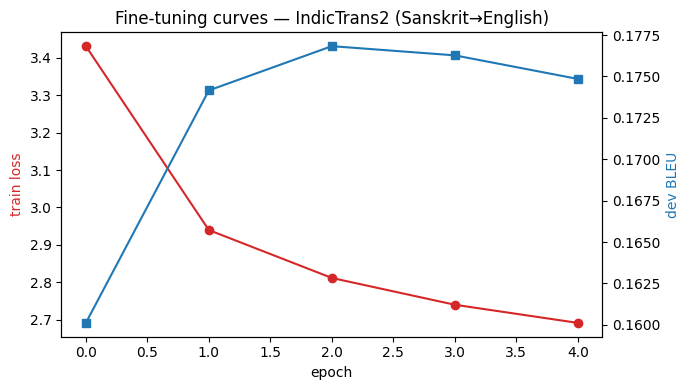

In [10]:
# ==============================================================================
# MODULE 5: TRAINING CURVES
# ==============================================================================
try:
    history
except NameError:
    with open(Cfg.HISTORY_PATH) as f:
        history = json.load(f)

fig, ax1 = plt.subplots(figsize=(7, 4))
ax1.plot(history["train_loss"], marker='o', color='tab:red', label='train loss')
ax1.set_xlabel('epoch'); ax1.set_ylabel('train loss', color='tab:red')
ax2 = ax1.twinx()
ax2.plot(history["dev_bleu"], marker='s', color='tab:blue', label='dev BLEU (proxy, greedy)')
ax2.set_ylabel('dev BLEU', color='tab:blue')
plt.title('Fine-tuning curves — IndicTrans2 (Sanskrit→English)')
fig.tight_layout()
plt.savefig(os.path.join(STORAGE_PATH, 'training_curves.png'), dpi=150)
plt.show()


---
## MODULE 6 — Test-set inference with beam search + timing
**Needs:** `model`, `tokenizer`, `ip` in memory (Module 0 + 2 must have run this
session), `test_df` (Module 1, auto-loaded from `.pkl`), and `Cfg.BEST_CKPT_PATH` on
disk (Module 4). Always **explicitly reloads the best fine-tuned checkpoint** from disk
before generating, so this module gives correct results regardless of what state
`model` happens to be in when you run it.
**Produces:** `predictions`, `test_ids`, `test_refs`, `inference_time_sec` in memory,
and `Cfg.PRED_PATH` on disk.

In [11]:
# ==============================================================================
# MODULE 6: TEST-SET BEAM-SEARCH INFERENCE + EFFICIENCY TIMING
# ==============================================================================
try:
    test_df
except NameError:
    test_df = pd.read_pickle(Cfg.TEST_DF_PKL)

assert 'model' in globals() and 'tokenizer' in globals() and 'ip' in globals(), \
    "Run MODULE 0 -> MODULE 2 first (need model/tokenizer/ip architecture in memory)."

model.load_state_dict(torch.load(Cfg.BEST_CKPT_PATH))   # always use the best fine-tuned weights
model.eval()

test_src_processed = ip.preprocess_batch(test_df['Sentence_sa'].tolist(), src_lang=Cfg.SRC_LANG, tgt_lang=Cfg.TGT_LANG)
test_ids  = test_df['Source_id'].tolist()
test_refs = test_df['Sentence_en'].tolist()

predictions_raw = []
inference_start = time.time()

with torch.no_grad():
    for i in range(0, len(test_src_processed), Cfg.EVAL_BATCH):
        batch_src = test_src_processed[i:i + Cfg.EVAL_BATCH]
        enc = tokenizer(batch_src, truncation=True, padding=True, max_length=Cfg.MAX_SRC_LEN, return_tensors="pt").to(DEVICE)
        gen = model.generate(**enc, num_beams=Cfg.NUM_BEAMS, max_length=Cfg.MAX_TGT_LEN, num_return_sequences=1)
        predictions_raw.extend(tokenizer.batch_decode(gen, skip_special_tokens=True))

inference_time_sec = time.time() - inference_start
predictions = ip.postprocess_batch(predictions_raw, lang=Cfg.TGT_LANG)

pd.DataFrame({"Source_id": test_ids, "Sentence_sa": test_df['Sentence_sa'].tolist(),
              "Reference": test_refs, "Prediction": predictions,
              "inference_time_sec_total": [inference_time_sec] * len(predictions)}
             ).to_csv(Cfg.PRED_PATH, index=False, encoding="utf-8")

print(f"Inference time (test set, beam={Cfg.NUM_BEAMS}): {inference_time_sec:.2f} sec for {len(predictions)} sentences")
print(f"Saved predictions -> {Cfg.PRED_PATH}")
for k in range(3):
    print(" SRC :", test_df['Sentence_sa'].iloc[k])
    print(" REF :", test_refs[k])
    print(" HYP :", predictions[k], "\n")


Inference time (test set, beam=5): 111.85 sec for 1000 sentences
Saved predictions -> /content/drive/MyDrive/Sanskrit_NMT_Project/test_predictions.csv
 SRC : एक्लिप्स् इति प्रोग्रामर् कृते दोषान्वेषणे अपि साहाय्यं करोति।
 REF : Eclipse also helps the programmer to find out errors.
 HYP : Eclipse also helps in bug detection for the programmer. 

 SRC : विश्वासकारणादेव समभाषि मया वचः। इति यथा शास्त्रे लिखितं तथैवास्माभिरपि विश्वासजनकम् आत्मानं प्राप्य विश्वासः क्रियते तस्माच्च वचांसि भाष्यन्ते।
 REF : "We having the same spirit of faith, according as it is written, I believed, and therefore have I spoken; we also believe, and therefore speak;"
 HYP : "For I have spoken by faith as it is written in the Scriptures saying We have the confidence of the Spirit and are persuaded. 

 SRC : तदा, तत्स्वयं ड्रैवर निमित्तम् अन्वेष्यति। अहं 'Cancel' इत्यस्योपरि नुदामि।
 REF : Then it will automatically begin searching for drivers. I will click on Cancel.
 HYP : Then it will search for its own driver

---
## MODULE 7 — Metrics: BLEU, BERTScore, Efficiency
**Needs:** `predictions`, `test_refs` (Module 6, auto-loaded from `Cfg.PRED_PATH` if
missing) and `model` in memory for the parameter count (Module 2).
**Produces:** printed metrics + `Cfg.METRICS_PATH` on disk.

In [12]:
# ==============================================================================
# MODULE 7: EVALUATION METRICS
# ==============================================================================
try:
    predictions, test_refs
except NameError:
    _pred_df = pd.read_csv(Cfg.PRED_PATH)
    predictions = _pred_df['Prediction'].tolist()
    test_refs   = _pred_df['Reference'].tolist()
    inference_time_sec = _pred_df['inference_time_sec_total'].iloc[0]

from nltk.translate.bleu_score import corpus_bleu
from bert_score import score as bertscore_score

tokenized_refs = [[r.split()] for r in test_refs]
tokenized_hyps = [h.split() for h in predictions]
bleu = corpus_bleu(tokenized_refs, tokenized_hyps)   # default NLTK weights, as required

P, R, F1 = bertscore_score(predictions, test_refs, lang="en", rescale_with_baseline=True, verbose=False)
bertscore_f1 = F1.mean().item()

assert 'model' in globals(), "Run MODULE 0 -> MODULE 2 first to get parameter counts from the loaded model."
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

metrics = {
    "BLEU": bleu,
    "BERTScore_F1_rescaled": bertscore_f1,
    "Inference_time_sec_test": inference_time_sec,
    "Total_parameters": total_params,
    "Trainable_parameters": trainable_params,
    "Pretrained_backbone": "ai4bharat/indictrans2-indic-en-dist-200M (full fine-tune)",
}
with open(Cfg.METRICS_PATH, 'w') as f:
    json.dump(metrics, f, indent=2)

print("="*60)
for k, v in metrics.items():
    print(f"{k:28s}: {v}")
print("="*60)


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BLEU                        : 0.20727711438853375
BERTScore_F1_rescaled       : 0.5613117814064026
Inference_time_sec_test     : 111.85436534881592
Total_parameters            : 211780608
Trainable_parameters        : 211780608
Pretrained_backbone         : ai4bharat/indictrans2-indic-en-dist-200M (full fine-tune)


---
## MODULE 8 — Write `submission.csv`
**Needs:** `predictions`, `test_ids` (Module 6, auto-loaded from `Cfg.PRED_PATH` if missing).
**Produces:** `Cfg.SUBMISSION_PATH` — the file required by Section 5/7 of the assignment.

In [13]:
# ==============================================================================
# MODULE 8: SUBMISSION FILE
# ==============================================================================
try:
    predictions, test_ids
except NameError:
    _pred_df = pd.read_csv(Cfg.PRED_PATH)
    predictions = _pred_df['Prediction'].tolist()
    test_ids    = _pred_df['Source_id'].tolist()

submission = pd.DataFrame({"Source_id": test_ids, "Sentence_en": predictions})
submission.to_csv(Cfg.SUBMISSION_PATH, index=False, encoding="utf-8")
print("Saved:", Cfg.SUBMISSION_PATH)
submission.head()


Saved: /content/drive/MyDrive/Sanskrit_NMT_Project/submission.csv


,Source_id,Sentence_en
0,1,Eclipse also helps in bug detection for the pr...
1,2,"""For I have spoken by faith as it is written i..."
2,3,Then it will search for its own driver. I will...
3,4,Iteration for all means that the iterator is s...
4,5,"""And I heard a voice saying The second sea com..."


---
## MODULE 9 — Report examples table
**Needs:** `Cfg.PRED_PATH` on disk (Module 6). Pick 5-10 rows (mix of good/bad cases)
for the Report's "Translation Examples / error analysis" section.

In [14]:
# ==============================================================================
# MODULE 9: EXAMPLES FOR REPORT
# ==============================================================================
examples = pd.read_csv(Cfg.PRED_PATH)[['Source_id', 'Sentence_sa', 'Reference', 'Prediction']]
examples.sample(10, random_state=42)


,Source_id,Sentence_sa,Reference,Prediction
521,522,स्वराक्षराणाम् 'अच्' इति नाम ।,The name of the vowels is “ach”.,The name of the vowel letters is Ach.
737,738,संस्कतज्ञानाभावे गीतायाः अवगमनं क्लेशाय एव ।,Lack of knowledge of Sanskrit is a problem for...,"""In the spirit of Sanskrit knowledge the devia..."
740,741,शनै: शनै: स्वपार्ष्णीम उत्थापयेत (यथा संभवम्) ...,3. Slowly raise the heels as much as you can a...,"""On Saturday and Saturday raise your heels (as..."
660,661,FrontAccounting इण्टर्फ़ेस् उद्घट्यते ।,The FrontAccounting interface opens.,FrontAccounting interface opens.
411,412,एषः रथः ।,This is a chariot.,This is a chariot.
678,679,यतः सा परिचर्य्या यै र्भद्ररूपेण साध्यते ते श्...,"""For they that have used the office of a deaco...","""Because by that ministry they receive the hig..."
626,627,तथा च यो नरः क्षेत्रे तिष्ठति सोपि स्ववस्त्रं ...,And let him that is in the field not turn back...,"""And whosoever is in the field let him not tur..."
513,514,"""ततः प्रभुः प्रोवाच, प्रभुः समुचितकाले निजपरिव...","""And the Lord said, Who then is that faithful ...","""And the Lord said unto him Who is this faithf..."
859,860,"उत्सरगतया, Unit penalty field इतीदं, 0.1 इति द...","The Unit penalty field, by default, shows 0.1 ...",At the beginning the Unit penalty field is sho...
136,137,अत्र वयं पश्याम: यत् write इति अनुमति: सर्वत...,Here we can see the write permission for all h...,Here we can see that the write permission has ...
